## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [33]:
! git clone https://github.com/SafaaMahbub/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/data/land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [5]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


(338, 4)

In [7]:
df['mine_type'].value_counts()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


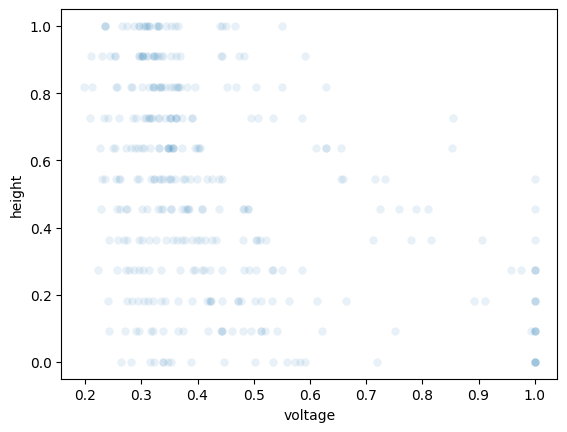

In [13]:
#plotting scatterplots
sns.scatterplot(data=df, x='voltage', y='height', alpha=.1)
plt.show()

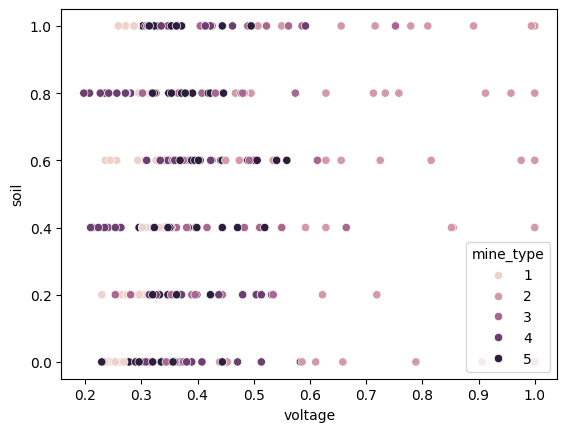

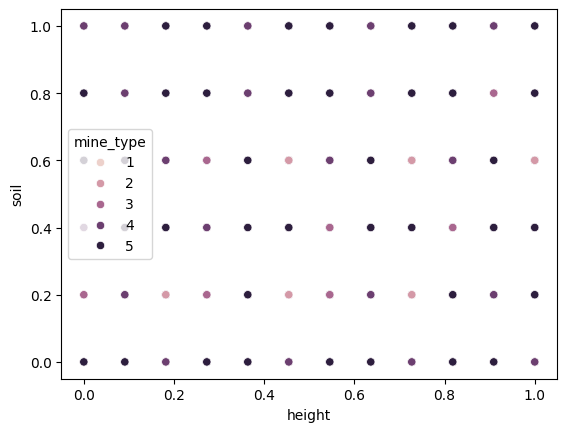

In [11]:
sns.scatterplot(data=df, x='voltage', y='soil', hue='mine_type')
plt.show()
sns.scatterplot(data=df, x='height', y='soil', hue='mine_type')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
u = df[['voltage', 'height', 'soil']]
y = df['mine_type']

u_train, u_test, y_train, y_test = train_test_split(u,y, # Feature and target variables
                                                    test_size=.5, # Split the sample 80 train/ 20 test
                                                    random_state=100) # For replication purposes

In [20]:
from sklearn.neighbors import KNeighborsClassifier
k = 5
# Create a fitted model instance:
model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
model = model.fit(u_train,y_train) # Fit the model, training set
y_hat = model.predict(u_test) # Predictions, test set
print("confusion matrix for k =5")
print( pd.crosstab(y_test, y_hat)) # Confusion matrix
model.score(u_test,y_test) # Test accuracy

confusion matrix for k =5
col_0       1   2   3  4   5
mine_type                   
1          22   0   8  5   3
2           0  22   9  1   3
3           6   1  10  6  10
4          10   2  13  5   5
5           9   1  11  5   2


0.3609467455621302

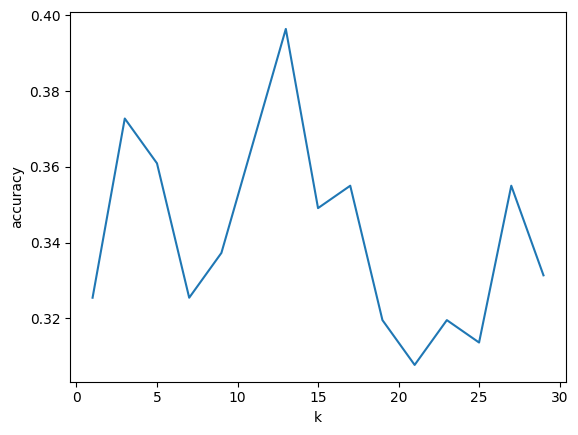

optimal k is 13
accuracy is 0.39644970414201186


In [25]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
k = range(1,30,2)
acc=[]
for i in k:
  model = KNeighborsClassifier(n_neighbors = i) # Create a model
  model = model.fit(u_train,y_train) # Fit the model
  y_hat = model.predict(u_test) # Predictions
  acc.append(model.score(u_test,y_test)) # Test accuracy
  #chatgot helped withthis
plt.plot(k,acc)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

optimal_k = k[acc.index(max(acc))]
print('optimal k is', optimal_k)
print('accuracy is', max(acc))

In [26]:
model = KNeighborsClassifier(n_neighbors = optimal_k) # Create a model
model = model.fit(u_train,y_train)

y_hat = model.predict(u_test)
print("confusion matrix for optimal k")
print( pd.crosstab(y_test, y_hat))

accuracy = model.score(u_test,y_test)
print('accuracy is', accuracy)

confusion matrix for optimal k
col_0       1   2   3  4   5
mine_type                   
1          26   0  10  0   2
2           0  21   7  2   5
3           3   3   8  0  19
4          17   0   7  4   7
5           7   0  13  0   8
accuracy is 0.39644970414201186


usign knn with the optimal number of k neighbout, the classification achived a accuracy of about 40 percent. the confusion matrix shoes that the first two thpes of mine types are classfiied most correclty, wjereas types 3 and 4 have more mistkaes. this aligns with the scatterplos from before.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

In [34]:
import pandas as pd

df= pd.read_csv('/content/data/zoo.csv')
df.head()

,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [36]:
print(df.columns)

Index(['animal', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic',
       'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins',
       'legs', 'tail', 'domestic', 'catsize', 'class'],
      dtype='object')


In [37]:
print(df['class'].value_counts())
#

class
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64


In [38]:
for i in df.columns[1:]:
  print(df.groupby('class')[i].value_counts())

class  hair
1      1       39
       0        2
2      0       20
3      0        5
4      0       13
5      0        4
6      0        4
       1        4
7      0       10
Name: count, dtype: int64
class  feathers
1      0           41
2      1           20
3      0            5
4      0           13
5      0            4
6      0            8
7      0           10
Name: count, dtype: int64
class  eggs
1      0       40
       1        1
2      1       20
3      1        4
       0        1
4      1       13
5      1        4
6      1        8
7      1        9
       0        1
Name: count, dtype: int64
class  milk
1      1       41
2      0       20
3      0        5
4      0       13
5      0        4
6      0        8
7      0       10
Name: count, dtype: int64
class  airborne
1      0           39
       1            2
2      1           16
       0            4
3      0            5
4      0           13
5      0            4
6      1            6
       0            2
7      0

In [44]:
print(df.drop(columns=['class','animal']).var().sort_values(ascending=False))

legs        4.134653
predator    0.249505
catsize     0.248317
hair        0.246931
eggs        0.245347
milk        0.243564
toothed     0.241584
aquatic     0.231683
tail        0.193069
airborne    0.182970
breathes    0.166337
feathers    0.160396
backbone    0.147921
fins        0.141386
domestic    0.113267
venomous    0.073663
dtype: float64


In [40]:
for i in range(1,8):
  print(f"class {i}:")
  print(df[df['class']==i]['animal'].tolist())

class 1:
['aardvark', 'antelope', 'bear', 'boar', 'buffalo', 'calf', 'cavy', 'cheetah', 'deer', 'dolphin', 'elephant', 'fruitbat', 'giraffe', 'girl', 'goat', 'gorilla', 'hamster', 'hare', 'leopard', 'lion', 'lynx', 'mink', 'mole', 'mongoose', 'opossum', 'oryx', 'platypus', 'polecat', 'pony', 'porpoise', 'puma', 'pussycat', 'raccoon', 'reindeer', 'seal', 'sealion', 'squirrel', 'vampire', 'vole', 'wallaby', 'wolf']
class 2:
['chicken', 'crow', 'dove', 'duck', 'flamingo', 'gull', 'hawk', 'kiwi', 'lark', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'rhea', 'skimmer', 'skua', 'sparrow', 'swan', 'vulture', 'wren']
class 3:
['pitviper', 'seasnake', 'slowworm', 'tortoise', 'tuatara']
class 4:
['bass', 'carp', 'catfish', 'chub', 'dogfish', 'haddock', 'herring', 'pike', 'piranha', 'seahorse', 'sole', 'stingray', 'tuna']
class 5:
['frog', 'frog', 'newt', 'toad']
class 6:
['flea', 'gnat', 'honeybee', 'housefly', 'ladybird', 'moth', 'termite', 'wasp']
class 7:
['clam', 'crab', 'crayfish', 'lobster

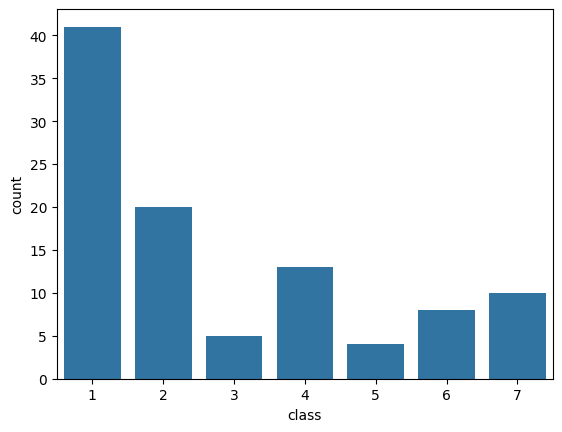

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='class')
plt.show()

based on the variaion of thevariables to relation to class, milk, eggs airbone, aquatic, hair, predator, catsize, ad legs are most suitable as they have the highest variation in the dataset and they identiy different animals

In [46]:
from sklearn.model_selection import train_test_split
u = df.drop(columns=['class','animal'])
y = df['class']

u_train, u_test, y_train, y_test = train_test_split(u,y, # Feature and target variables
                                                    test_size=.5, # Split the sample 80 train/ 20 test
                                                    random_state=100) # For replication purposes

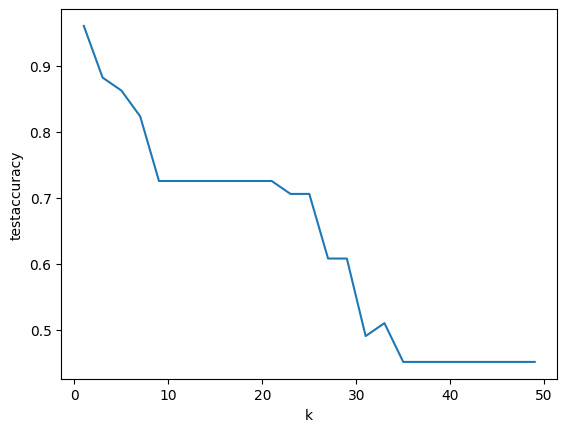

optimal k is 1
accuracy is 0.9607843137254902


In [49]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
k = range(1,50,2)
acc=[]
for i in k:
  #chatgpt helped me with this
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(u_train, y_train)           # Train model
  acc.append(model.score(u_test, y_test))  # Correct: use true labels

  #chatgot helped withthis
plt.plot(k,acc)
plt.xlabel('k')
plt.ylabel('testaccuracy')
plt.show()

optimal_k = k[acc.index(max(acc))]
print('optimal k is', optimal_k)
print('accuracy is', max(acc))

k=1 is the optimal k value on this test split, but it also shows signs of overfitting.

In [50]:
model = KNeighborsClassifier(n_neighbors=1)
model.fit(u_train, y_train)
y_hat = model.predict(u_test)

In [51]:
print("confusion matrix for optimal k")
print( pd.crosstab(y_test, y_hat))

accuracy = model.score(u_test,y_test)
print('accuracy is', accuracy)

confusion matrix for optimal k
col_0   1   2  3  4  5  6  7
class                       
1      23   0  0  0  0  0  0
2       0  12  0  0  0  0  0
3       0   0  1  1  1  0  0
4       0   0  0  3  0  0  0
5       0   0  0  0  3  0  0
6       0   0  0  0  0  5  0
7       0   0  0  0  0  0  2
accuracy is 0.9607843137254902


This model achieves an accuracy of around 96% with most classes predicting correclty.Mistakes tend to happen in class 3 eith class4 and 5.

In [55]:
#chatgpt helped me code
X_train_small = u_train[['milk', 'aquatic', 'airborne']]
X_test_small = u_test[['milk', 'aquatic', 'airborne']]

model_reduced = KNeighborsClassifier(n_neighbors=1)
model_reduced.fit(X_train_small, y_train)

y_hat_small = model_reduced.predict(X_test_small)

In [57]:
import pandas as pd
print("confusion matrix milk, aquatic, and airbone")
print( pd.crosstab(y_test, y_hat_small))

accuracy = model_reduced.score(X_test_small,y_test)
print('accuracy is', accuracy)

confusion matrix milk, aquatic, and airbone
col_0   1  2  4  6
class             
1      23  0  0  0
2       0  4  0  8
3       0  2  1  0
4       0  0  3  0
5       0  0  3  0
6       0  1  0  4
7       0  0  2  0
accuracy is 0.6666666666666666


In [58]:
probs = model_reduced.predict_proba(X_test_small)
probs_df = pd.DataFrame(probs, columns=model_reduced.classes_)
print(probs_df)

      1    2    3    4    5    6    7
0   0.0  0.0  0.0  0.0  0.0  1.0  0.0
1   0.0  0.0  0.0  1.0  0.0  0.0  0.0
2   0.0  0.0  0.0  1.0  0.0  0.0  0.0
3   1.0  0.0  0.0  0.0  0.0  0.0  0.0
4   1.0  0.0  0.0  0.0  0.0  0.0  0.0
5   0.0  0.0  0.0  1.0  0.0  0.0  0.0
6   1.0  0.0  0.0  0.0  0.0  0.0  0.0
7   0.0  1.0  0.0  0.0  0.0  0.0  0.0
8   0.0  1.0  0.0  0.0  0.0  0.0  0.0
9   0.0  1.0  0.0  0.0  0.0  0.0  0.0
10  1.0  0.0  0.0  0.0  0.0  0.0  0.0
11  0.0  0.0  0.0  0.0  0.0  1.0  0.0
12  1.0  0.0  0.0  0.0  0.0  0.0  0.0
13  0.0  1.0  0.0  0.0  0.0  0.0  0.0
14  0.0  1.0  0.0  0.0  0.0  0.0  0.0
15  1.0  0.0  0.0  0.0  0.0  0.0  0.0
16  0.0  0.0  0.0  1.0  0.0  0.0  0.0
17  1.0  0.0  0.0  0.0  0.0  0.0  0.0
18  0.0  1.0  0.0  0.0  0.0  0.0  0.0
19  0.0  0.0  0.0  0.0  0.0  1.0  0.0
20  1.0  0.0  0.0  0.0  0.0  0.0  0.0
21  1.0  0.0  0.0  0.0  0.0  0.0  0.0
22  0.0  0.0  0.0  0.0  0.0  1.0  0.0
23  0.0  0.0  0.0  0.0  0.0  1.0  0.0
24  1.0  0.0  0.0  0.0  0.0  0.0  0.0
25  1.0  0.0

These results show that not all classes are being represeneted. Only classes1,2,4,6 have non-zero values. This can stem that milk, aquatic and airbone might not be able to distinguish all clases. This model shoes some underlying bias toward the classes that are able to be seperated and therefore the accuracy drops.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)